In [1]:
import scanpy as sc
import anndata as ad
import scanpy.external as sce

import pandas as pd
import numpy as np

import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

import gseapy as gp

import matplotlib.pyplot as plt
import seaborn as sns

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # disable GPU

import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))  # should be []

from sccoda.util import comp_ana as mod
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz
import sccoda.datasets as scd
import arviz as az

import scvi
import torch
import scipy.sparse as sp

from rich import print
import warnings
warnings.filterwarnings("ignore")

outdir = "/scratch/user/s4575250/BIOX7018_thesis/write/03_sccoda_DA/PICA_Batch001-Batch007"
os.makedirs(outdir, exist_ok=True)
sc.settings.figdir = "/scratch/user/s4575250/BIOX7018_thesis/figures/PICA0001-PICA0007/03_sccoda"

2025-12-14 21:03:34.581181: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-14 21:03:34.818606: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-14 21:03:36.763882: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[]


2025-12-14 21:03:37.448528: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-12-14 21:03:37.448598: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2025-12-14 21:03:37.448604: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-12-14 21:03:37.448608: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-12-14 21:03:37.448618: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: bun122
2025-12-14 21:03:37.448621: I external/local_xla/xla/stream_executor/cuda/cuda_d

### Abundance analysis (sccoda)

In [2]:
adata_age_cd4= sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.h5ad")

In [3]:
adata_age_cd4.obs['cell_type'].unique()
adata_age_cd4.obs['cell_type'].value_counts()

cell_type
Naive/Central memory CD4 T cell    352568
CCR4+ CCR6+ memory CD4 T cell       32809
TOX+ CD4 T cell                     25003
Tfh                                 22711
Tfh cell                            21688
Th2 cell                            18195
Th2-like T cell                     17054
TIGIT+ TOX+ memory CD4 T cell       16203
CCR6+ memory CD4 T cell             15731
CCR6+ CD4 T cell                     7431
CTLA4+ TOX+ CD4 T cell               7049
CCR4+ CD4 T cell                     5546
Treg                                 2566
Cytotoxic CD4 T cell                 2436
Th2                                  2333
CCR4+ memory CD4 T cell              2186
Unknown CD4 T cell                    559
Innate-like CD4 T cell                165
Regulatory T cell                      50
Name: count, dtype: int64

In [4]:
pd.crosstab(adata_age_cd4.obs["pica_id"], adata_age_cd4.obs["cell_type"])

cell_type,CCR4+ CCR6+ memory CD4 T cell,CCR4+ CD4 T cell,CCR4+ memory CD4 T cell,CCR6+ CD4 T cell,CCR6+ memory CD4 T cell,CTLA4+ TOX+ CD4 T cell,Cytotoxic CD4 T cell,Innate-like CD4 T cell,Naive/Central memory CD4 T cell,Regulatory T cell,TIGIT+ TOX+ memory CD4 T cell,TOX+ CD4 T cell,Tfh,Tfh cell,Th2,Th2 cell,Th2-like T cell,Treg,Unknown CD4 T cell
pica_id,,,,,,,,,,,,,,,,,,,
PICA0001,0,0,0,0,11,0,32,0,2315,5,0,0,0,0,0,0,0,0,0
PICA0002,0,0,0,0,88,0,1,0,888,7,0,0,0,0,0,0,0,0,0
PICA0003,0,0,0,0,9,0,1,0,1118,6,0,0,0,0,0,0,0,0,0
PICA0004,0,0,0,0,10,0,3,0,1150,9,0,0,0,0,0,0,0,0,0
PICA0005,0,0,0,0,63,0,3,0,608,6,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PICA0164,0,0,0,0,0,0,2,0,4440,0,0,0,355,0,0,0,327,18,30
PICA0166,0,0,0,0,0,0,0,0,4758,0,0,0,135,0,0,0,118,18,20
PICA0168,0,0,0,0,0,0,69,0,2198,0,0,0,748,0,0,0,2282,14,119


In [5]:
pd.crosstab(
    adata_age_cd4.obs["pica_id"],
    adata_age_cd4.obs["cell_type"],
    normalize="index"
).round(3)

cell_type,CCR4+ CCR6+ memory CD4 T cell,CCR4+ CD4 T cell,CCR4+ memory CD4 T cell,CCR6+ CD4 T cell,CCR6+ memory CD4 T cell,CTLA4+ TOX+ CD4 T cell,Cytotoxic CD4 T cell,Innate-like CD4 T cell,Naive/Central memory CD4 T cell,Regulatory T cell,TIGIT+ TOX+ memory CD4 T cell,TOX+ CD4 T cell,Tfh,Tfh cell,Th2,Th2 cell,Th2-like T cell,Treg,Unknown CD4 T cell
pica_id,,,,,,,,,,,,,,,,,,,
PICA0001,0.0,0.0,0.0,0.0,0.005,0.0,0.014,0.0,0.980,0.002,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.000,0.000
PICA0002,0.0,0.0,0.0,0.0,0.089,0.0,0.001,0.0,0.902,0.007,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.000,0.000
PICA0003,0.0,0.0,0.0,0.0,0.008,0.0,0.001,0.0,0.986,0.005,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.000,0.000
PICA0004,0.0,0.0,0.0,0.0,0.009,0.0,0.003,0.0,0.981,0.008,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.000,0.000
PICA0005,0.0,0.0,0.0,0.0,0.093,0.0,0.004,0.0,0.894,0.009,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PICA0164,0.0,0.0,0.0,0.0,0.000,0.0,0.000,0.0,0.858,0.000,0.0,0.0,0.069,0.0,0.0,0.0,0.063,0.003,0.006
PICA0166,0.0,0.0,0.0,0.0,0.000,0.0,0.000,0.0,0.942,0.000,0.0,0.0,0.027,0.0,0.0,0.0,0.023,0.004,0.004
PICA0168,0.0,0.0,0.0,0.0,0.000,0.0,0.013,0.0,0.405,0.000,0.0,0.0,0.138,0.0,0.0,0.0,0.420,0.003,0.022


In [6]:
# Setup cell type by donor table
ct_table = (
    adata_age_cd4.obs.groupby(["pica_id", "cell_type"])
    .size()
    .unstack(fill_value=0)
)

print("ct_table shape:", ct_table.shape)
print(ct_table)

ct_table shape:
(128, 19)

cell_type  CCR4+ CCR6+ memory CD4 T cell  CCR4+ CD4 T cell  \
pica_id                                                      
PICA0001                               0                 0   
PICA0002                               0                 0   
PICA0003                               0                 0   
PICA0004                               0                 0   
PICA0005                               0                 0   
...                                  ...               ...   
PICA0164                               0                 0   
PICA0166                               0                 0   
PICA0168                               0                 0   
PICA0169                               0                 0   
PICA0173                               0                 0   

cell_type  CCR4+ memory CD4 T cell  CCR6+ CD4 T cell  CCR6+ memory CD4 T cell  \
pica_id                                                                         
PICA0001                         0                 0                       11   
PICA0002                         0                 0                       88   
PICA0003                         0                 0                        9   
PICA0004                         0                 0                       10   
PICA0005                         0                 0                       63   
...                            ...               ...                      ...   
PICA0164                         0                 0                        0   
PICA0166                         0                 0                        0   
PICA0168                         0                 0                        0   
PICA0169                         0                 0                        0   
PICA0173                         0                 0                        0   

cell_type  CTLA4+ TOX+ CD4 T cell  Cytotoxic CD4 T cell  \
pica_id                                                   
PICA0001                        0                    32   
PICA0002                        0                     1   
PICA0003                        0                     1   
PICA0004                        0                     3   
PICA0005                        0                     3   
...                           ...                   ...   
PICA0164                        0                     2   
PICA0166                        0                     0   
PICA0168                        0                    69   
PICA0169                        0                    10   
PICA0173                        0                   113   

cell_type  Innate-like CD4 T cell  Naive/Central memory CD4 T cell  \
pica_id                                                              
PICA0001                        0                             2315   
PICA0002                        0                              888   
PICA0003                        0                             1118   
PICA0004                        0                             1150   
PICA0005                        0                              608   
...                           ...                              ...   
PICA0164                        0                             4440   
PICA0166                        0                             4758   
PICA0168                        0                             2198   
PICA0169                        0                             2253   
PICA0173                        0                             3053   

cell_type  Regulatory T cell  TIGIT+ TOX+ memory CD4 T cell  TOX+ CD4 T cell  \
pica_id                                                                        
PICA0001                   5                              0                0   
PICA0002                   7                              0                0   
PICA0003                   6                              0                0   
PICA0004                   9                              0 

## Creating scCODA object for larger datasets
- using Age_group instead of Age in years int

In [7]:
meta_df = (
    adata_age_cd4.obs[["pica_id", "Age_group"]]
    .drop_duplicates()
    .set_index("pica_id")
)
print("Metadata shape:", meta_df.shape)
print(meta_df)

Metadata shape:
(128, 1)

Age_group
pica_id           
PICA0022     11–14
PICA0020     15–18
PICA0023       4–6
PICA0009       4–6
PICA0008      7–10
...            ...
PICA0001       0–3
PICA0003       0–3
PICA0006       0–3
PICA0004       0–3
PICA0005      7–10

[128 rows x 1 columns]

In [8]:
# align indexes
ct_index = ct_table.index.astype(str)
meta_index = meta_df.index.astype(str)

ct_table.index = ct_index
meta_df.index = meta_index

# Add Age_group column by explicit reindexing
ct_table_with_meta = ct_table.copy()
ct_table_with_meta["Age_group"] = meta_df["Age_group"].reindex(ct_table.index)

print(ct_table_with_meta.head())
print(ct_table_with_meta.columns)


cell_type  CCR4+ CCR6+ memory CD4 T cell  CCR4+ CD4 T cell  \
pica_id                                                      
PICA0001                               0                 0   
PICA0002                               0                 0   
PICA0003                               0                 0   
PICA0004                               0                 0   
PICA0005                               0                 0   

cell_type  CCR4+ memory CD4 T cell  CCR6+ CD4 T cell  CCR6+ memory CD4 T cell  \
pica_id                                                                         
PICA0001                         0                 0                       11   
PICA0002                         0                 0                       88   
PICA0003                         0                 0                        9   
PICA0004                         0                 0                       10   
PICA0005                         0                 0                       63   

cell_type  CTLA4+ TOX+ CD4 T cell  Cytotoxic CD4 T cell  \
pica_id                                                   
PICA0001                        0                    32   
PICA0002                        0                     1   
PICA0003                        0                     1   
PICA0004                        0                     3   
PICA0005                        0                     3   

cell_type  Innate-like CD4 T cell  Naive/Central memory CD4 T cell  \
pica_id                                                              
PICA0001                        0                             2315   
PICA0002                        0                              888   
PICA0003                        0                             1118   
PICA0004                        0                             1150   
PICA0005                        0                              608   

cell_type  Regulatory T cell  TIGIT+ TOX+ memory CD4 T cell  TOX+ CD4 T cell  \
pica_id                                                                        
PICA0001                   5                              0                0   
PICA0002                   7                              0                0   
PICA0003                   6                              0                0   
PICA0004                   9                              0                0   
PICA0005                   6                              0                0   

cell_type  Tfh  Tfh cell  Th2  Th2 cell  Th2-like T cell  Treg  \
pica_id                                                          
PICA0001     0         0    0         0                0     0   
PICA0002     0         0    0         0                0     0   
PICA0003     0         0    0         0                0     0   
PICA0004     0         0    0         0                0     0   
PICA0005     0         0    0         0                0     0   

cell_type  Unknown CD4 T cell Age_group  
pica_id                                  
PICA0001                    0       0–3  
PICA0002                    0     15–18  
PICA0003                    0       0–3  
PICA0004                    0       0–3  
PICA0005                    0      7–10

Index(['CCR4+ CCR6+ memory CD4 T cell', 'CCR4+ CD4 T cell',
       'CCR4+ memory CD4 T cell', 'CCR6+ CD4 T cell',
       'CCR6+ memory CD4 T cell', 'CTLA4+ TOX+ CD4 T cell',
       'Cytotoxic CD4 T cell', 'Innate-like CD4 T cell',
       'Naive/Central memory CD4 T cell', 'Regulatory T cell',
       'TIGIT+ TOX+ memory CD4 T cell', 'TOX+ CD4 T cell', 'Tfh', 'Tfh cell',
       'Th2', 'Th2 cell', 'Th2-like T cell', 'Treg', 'Unknown CD4 T cell',
       'Age_group'],
      dtype='object', name='cell_type')

In [9]:
# create scCODA data object
sccoda_data = dat.from_pandas(ct_table_with_meta, ["Age_group"])

print(sccoda_data)

AnnData object with n_obs × n_vars = 128 × 19
    obs: 'Age_group'

In [10]:
ct_table_with_meta["Age_group"].isna().sum()


np.int64(0)

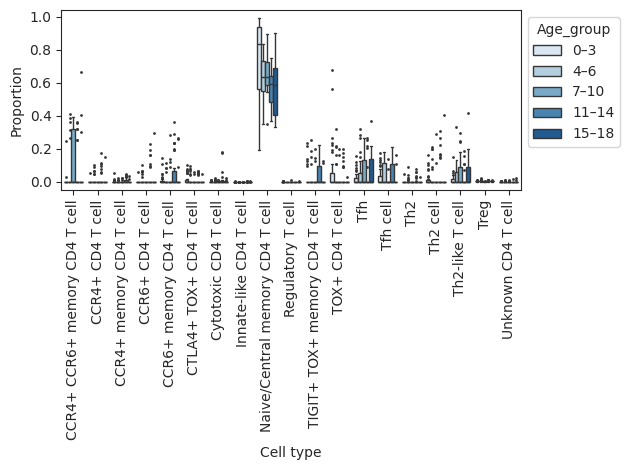

In [11]:
# check input to scCODA
viz.boxplots(sccoda_data, feature_name="Age_group")
plt.show()

In [12]:
# determine reference cell type
stats = pd.DataFrame({
    "nonzero_donors": (ct_table > 0).sum(0),
    "min_count": ct_table.min(0),
    "median_count": ct_table.median(0),
    "cv": (ct_table.std(0) / (ct_table.mean(0) + 1e-9))  # coefficient of variation
}).sort_values(["nonzero_donors", "median_count", "cv"], ascending=[False, False, True])

print(stats.head(8))

nonzero_donors  min_count  median_count  \
cell_type                                                                  
Naive/Central memory CD4 T cell             128        608        2608.5   
Treg                                        121          0          15.0   
Cytotoxic CD4 T cell                         54          0           0.0   
Tfh cell                                     39          0           0.0   
Tfh                                          36          0           0.0   
Th2-like T cell                              36          0           0.0   
CCR6+ memory CD4 T cell                      31          0           0.0   
TIGIT+ TOX+ memory CD4 T cell                24          0           0.0   

                                       cv  
cell_type                                  
Naive/Central memory CD4 T cell  0.432943  
Treg                             0.785357  
Cytotoxic CD4 T cell             4.068613  
Tfh cell                         1.648888  
Tfh                              1.931340  
Th2-like T cell                  2.219440  
CCR6+ memory CD4 T cell          2.396451  
TIGIT+ TOX+ memory CD4 T cell    2.221522

In [14]:
# run scCODA compositional analysis
model = mod.CompositionalAnalysis(
    formula="Age_group",                            
    data=sccoda_data,
    reference_cell_type="Naive/Central memory CD4 T cell"
)  

age_results = model.sample_hmc(num_results=20000)

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [01:33<00:00, 213.26it/s]


MCMC sampling finished. (118.489 sec)
Acceptance rate: 59.8%


In [15]:
age_results.summary_extended()


Compositional Analysis summary (extended):

Data: 128 samples, 19 cell types
Reference index: 8
Formula: Age_group
Spike-and-slab threshold: 1.000

MCMC Sampling: Sampled 20000 chain states (5000 burnin samples) in 118.489 sec. Acceptance rate: 59.8%

Intercepts:
                                 Final Parameter  HDI 3%  HDI 97%     SD  \
Cell Type                                                                  
CCR4+ CCR6+ memory CD4 T cell             -1.750  -1.921   -1.572  0.094   
CCR4+ CD4 T cell                          -1.868  -2.038   -1.696  0.092   
CCR4+ memory CD4 T cell                   -1.821  -1.995   -1.652  0.092   
CCR6+ CD4 T cell                          -1.832  -2.001   -1.652  0.093   
CCR6+ memory CD4 T cell                   -1.711  -1.890   -1.534  0.095   
CTLA4+ TOX+ CD4 T cell                    -1.764  -1.952   -1.595  0.095   
Cytotoxic CD4 T cell                      -1.741  -1.915   -1.568  0.091   
Innate-like CD4 T cell                    -1.892  -2

In [18]:
# credible effect summary
credible=age_results.credible_effects().reset_index()
print(credible)

Covariate                      Cell Type  Final Parameter
0     Age_group[T.4–6]  CCR4+ CCR6+ memory CD4 T cell            False
1     Age_group[T.4–6]               CCR4+ CD4 T cell            False
2     Age_group[T.4–6]        CCR4+ memory CD4 T cell            False
3     Age_group[T.4–6]               CCR6+ CD4 T cell            False
4     Age_group[T.4–6]        CCR6+ memory CD4 T cell            False
..                 ...                            ...              ...
71  Age_group[T.15–18]                            Th2            False
72  Age_group[T.15–18]                       Th2 cell            False
73  Age_group[T.15–18]                Th2-like T cell            False
74  Age_group[T.15–18]                           Treg            False
75  Age_group[T.15–18]             Unknown CD4 T cell            False

[76 rows x 3 columns]

In [19]:
intercepts_df = age_results.intercept_df.reset_index()
effects_df = age_results.effect_df.reset_index()

intercepts_df.to_csv("/scratch/user/s4575250/BIOX7018_thesis/data/figures/PICA_Batch001-Batch007/03_sccoda/cd4_age_sccoda_intercepts.csv", index=False)
effects_df.to_csv("/scratch/user/s4575250/BIOX7018_thesis/data/figures/PICA_Batch001-Batch007/03_sccoda/cd4_age_sccoda_effects.csv", index=False)
credible.to_csv("/scratch/user/s4575250/BIOX7018_thesis/data/figures/PICA_Batch001-Batch007/03_sccoda/cd4_age_sccoda_credible_effects.csv", index=False)

In [20]:
# extract coefficients summary dataframe
summary_df = az.summary(age_results)
print(summary_df.head())

arviz - WARNING - Shape validation failed: input_shape: (1, 15000), minimum_shape: (chains=2, draws=4)


mean     sd  hdi_3%  hdi_97%  \
alpha[CCR4+ CCR6+ memory CD4 T cell] -1.750  0.094  -1.921   -1.572   
alpha[CCR4+ CD4 T cell]              -1.868  0.092  -2.038   -1.696   
alpha[CCR4+ memory CD4 T cell]       -1.821  0.092  -1.995   -1.652   
alpha[CCR6+ CD4 T cell]              -1.832  0.093  -2.001   -1.652   
alpha[CCR6+ memory CD4 T cell]       -1.711  0.095  -1.890   -1.534   

                                      mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha[CCR4+ CCR6+ memory CD4 T cell]      0.005    0.002     378.0    1071.0   
alpha[CCR4+ CD4 T cell]                   0.006    0.002     253.0    1033.0   
alpha[CCR4+ memory CD4 T cell]            0.004    0.002     442.0    1186.0   
alpha[CCR6+ CD4 T cell]                   0.004    0.002     485.0    1079.0   
alpha[CCR6+ memory CD4 T cell]            0.004    0.002     564.0    1133.0   

                                      r_hat  
alpha[CCR4+ CCR6+ memory CD4 T cell]    NaN  
alpha[CCR4+ CD4 T cell]                 NaN  
alpha[CCR4+ memory CD4 T cell]          NaN  
alpha[CCR6+ CD4 T cell]                 NaN  
alpha[CCR6+ memory CD4 T cell]          NaN

In [21]:
coef_df = summary_df[summary_df.index.str.startswith("beta[Age_group")].copy()
coef_df.rename(columns={"hdi_3%": "hdi_3", "hdi_97%": "hdi_97"}, inplace=True)
print(coef_df.head())


mean     sd  hdi_3  \
beta[Age_group[T.4–6], CCR4+ CCR6+ memory CD4 T... -0.018  0.055 -0.146   
beta[Age_group[T.4–6], CCR4+ CD4 T cell]            0.028  0.063 -0.043   
beta[Age_group[T.4–6], CCR4+ memory CD4 T cell]    -0.004  0.074 -0.170   
beta[Age_group[T.4–6], CCR6+ CD4 T cell]            0.004  0.045 -0.077   
beta[Age_group[T.4–6], CCR6+ memory CD4 T cell]    -0.022  0.064 -0.162   

                                                    hdi_97  mcse_mean  \
beta[Age_group[T.4–6], CCR4+ CCR6+ memory CD4 T...   0.071      0.011   
beta[Age_group[T.4–6], CCR4+ CD4 T cell]             0.181      0.020   
beta[Age_group[T.4–6], CCR4+ memory CD4 T cell]      0.152      0.017   
beta[Age_group[T.4–6], CCR6+ CD4 T cell]             0.097      0.005   
beta[Age_group[T.4–6], CCR6+ memory CD4 T cell]      0.033      0.016   

                                                    mcse_sd  ess_bulk  \
beta[Age_group[T.4–6], CCR4+ CCR6+ memory CD4 T...    0.006      16.0   
beta[Age_group[T.4–6], CCR4+ CD4 T cell]              0.011       4.0   
beta[Age_group[T.4–6], CCR4+ memory CD4 T cell]       0.025      17.0   
beta[Age_group[T.4–6], CCR6+ CD4 T cell]              0.007      43.0   
beta[Age_group[T.4–6], CCR6+ memory CD4 T cell]       0.019       7.0   

                                                    ess_tail  r_hat  
beta[Age_group[T.4–6], CCR4+ CCR6+ memory CD4 T...     121.0    NaN  
beta[Age_group[T.4–6], CCR4+ CD4 T cell]                31.0    NaN  
beta[Age_group[T.4–6], CCR4+ memory CD4 T cell]         18.0    NaN  
beta[Age_group[T.4–6], CCR6+ CD4 T cell]                81.0    NaN  
beta[Age_group[T.4–6], CCR6+ memory CD4 T cell]         30.0    NaN

In [22]:
# parse cell type from index and sort by mean coefficient
idx = coef_df.index.to_series().astype(str)

coef_df["Age_group"] = idx.str.extract(r"Age_group\[(.*?)\]")
coef_df["cell_type"]  = idx.str.extract(r", (.*?)\]")
coef_df = coef_df.sort_values(["Age_group", "mean"], ascending=[True, False])

print(coef_df.head())

mean     sd  hdi_3  \
beta[Age_group[T.11–14], Tfh cell]                  0.034  0.088 -0.091   
beta[Age_group[T.11–14], TIGIT+ TOX+ memory CD4...  0.033  0.076 -0.089   
beta[Age_group[T.11–14], Innate-like CD4 T cell]    0.023  0.058 -0.074   
beta[Age_group[T.11–14], CCR4+ CCR6+ memory CD4...  0.018  0.058 -0.095   
beta[Age_group[T.11–14], CCR4+ memory CD4 T cell]   0.018  0.059 -0.086   

                                                    hdi_97  mcse_mean  \
beta[Age_group[T.11–14], Tfh cell]                   0.251      0.028   
beta[Age_group[T.11–14], TIGIT+ TOX+ memory CD4...   0.205      0.028   
beta[Age_group[T.11–14], Innate-like CD4 T cell]     0.144      0.022   
beta[Age_group[T.11–14], CCR4+ CCR6+ memory CD4...   0.146      0.009   
beta[Age_group[T.11–14], CCR4+ memory CD4 T cell]    0.148      0.013   

                                                    mcse_sd  ess_bulk  \
beta[Age_group[T.11–14], Tfh cell]                    0.030      11.0   
beta[Age_group[T.11–14], TIGIT+ TOX+ memory CD4...    0.006       4.0   
beta[Age_group[T.11–14], Innate-like CD4 T cell]      0.006       3.0   
beta[Age_group[T.11–14], CCR4+ CCR6+ memory CD4...    0.010      27.0   
beta[Age_group[T.11–14], CCR4+ memory CD4 T cell]     0.009      12.0   

                                                    ess_tail  r_hat Age_group  \
beta[Age_group[T.11–14], Tfh cell]                      26.0    NaN   T.11–14   
beta[Age_group[T.11–14], TIGIT+ TOX+ memory CD4...      14.0    NaN   T.11–14   
beta[Age_group[T.11–14], Innate-like CD4 T cell]       129.0    NaN   T.11–14   
beta[Age_group[T.11–14], CCR4+ CCR6+ memory CD4...      73.0    NaN   T.11–14   
beta[Age_group[T.11–14], CCR4+ memory CD4 T cell]       66.0    NaN   T.11–14   

                                                                        cell_type  
beta[Age_group[T.11–14], Tfh cell]                                       Tfh cell  
beta[Age_group[T.11–14], TIGIT+ TOX+ memory CD4...  TIGIT+ TOX+ memory CD4 T cell  
beta[Age_group[T.11–14], Innate-like CD4 T cell]           Innate-like CD4 T cell  
beta[Age_group[T.11–14], CCR4+ CCR6+ memory CD4...  CCR4+ CCR6+ memory CD4 T cell  
beta[Age_group[T.11–14], CCR4+ memory CD4 T cell]         CCR4+ memory CD4 T cell

In [23]:
coef_df[["Age_group", "cell_type", "mean", "hdi_3", "hdi_97"]].head()

,Age_group,cell_type,mean,hdi_3,hdi_97
"beta[Age_group[T.11–14], Tfh cell]",T.11–14,Tfh cell,0.034,-0.091,0.251
"beta[Age_group[T.11–14], TIGIT+ TOX+ memory CD4 T cell]",T.11–14,TIGIT+ TOX+ memory CD4 T cell,0.033,-0.089,0.205
"beta[Age_group[T.11–14], Innate-like CD4 T cell]",T.11–14,Innate-like CD4 T cell,0.023,-0.074,0.144
"beta[Age_group[T.11–14], CCR4+ CCR6+ memory CD4 T cell]",T.11–14,CCR4+ CCR6+ memory CD4 T cell,0.018,-0.095,0.146
"beta[Age_group[T.11–14], CCR4+ memory CD4 T cell]",T.11–14,CCR4+ memory CD4 T cell,0.018,-0.086,0.148


In [51]:
age_ref_for_order = "T.15–18"

order_df = (
    coef_df[coef_df["Age_group"] == age_ref_for_order]
    .sort_values("mean")          # smallest (most negative) at top
)
cell_type_order = order_df["cell_type"].tolist()

print("Number of CD4 subsets:", len(cell_type_order))
print(cell_type_order)

Number of CD4 subsets: 19

[
    'CCR6+ CD4 T cell',
    'Cytotoxic CD4 T cell',
    'CCR4+ memory CD4 T cell',
    'Treg',
    'Tfh cell',
    'CCR4+ CCR6+ memory CD4 T cell',
    'TOX+ CD4 T cell',
    'Unknown CD4 T cell',
    'Innate-like CD4 T cell',
    'Th2 cell',
    'Naive/Central memory CD4 T cell',
    'CTLA4+ TOX+ CD4 T cell',
    'Tfh',
    'Regulatory T cell',
    'CCR6+ memory CD4 T cell',
    'TIGIT+ TOX+ memory CD4 T cell',
    'Th2-like T cell',
    'CCR4+ CD4 T cell',
    'Th2'
]

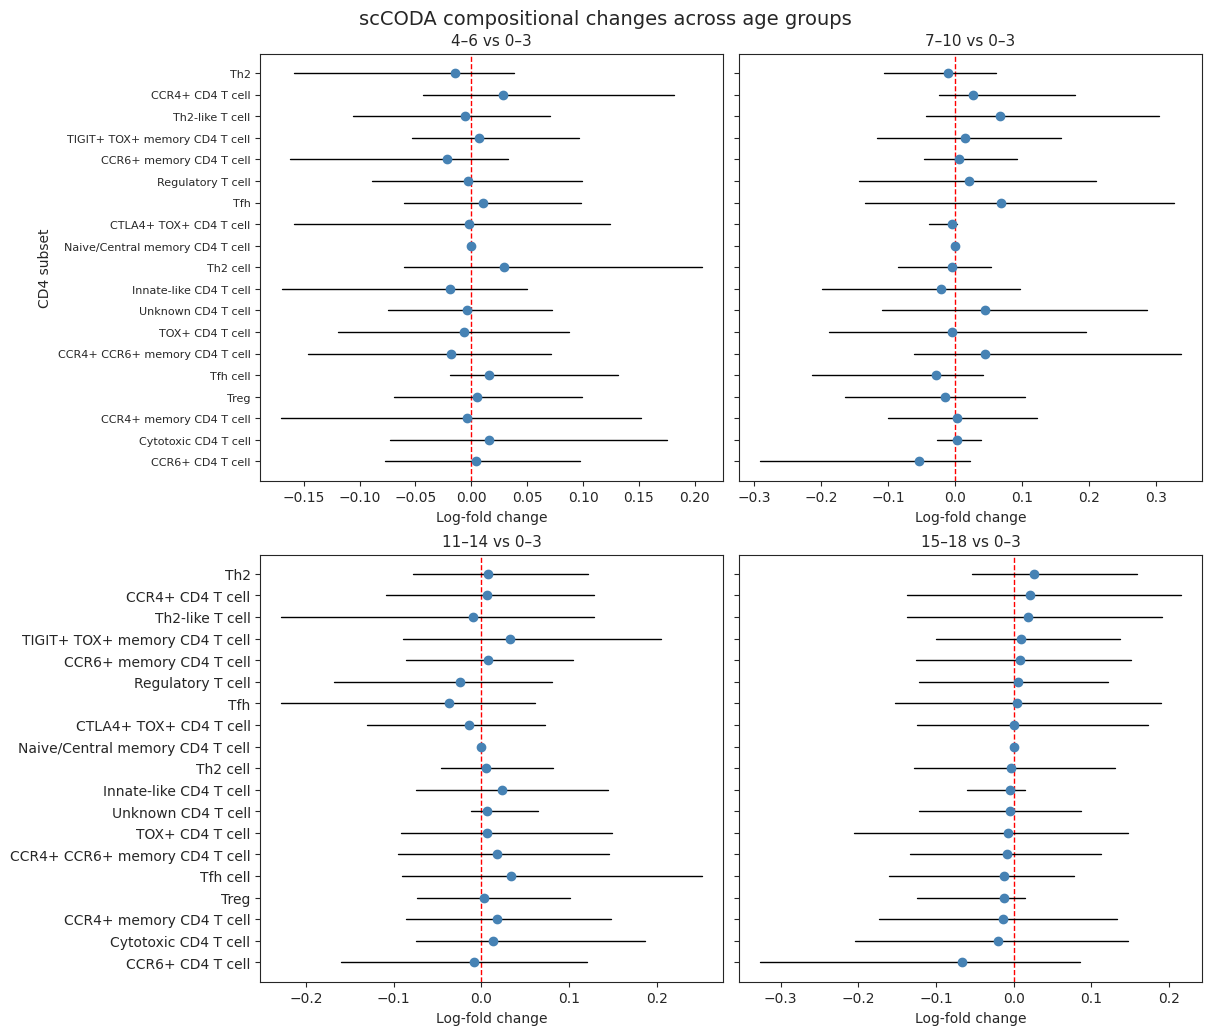

In [52]:
age_levels = ["T.4–6", "T.7–10", "T.11–14", "T.15–18"]
titles = ["4–6 vs 0–3", "7–10 vs 0–3", "11–14 vs 0–3", "15–18 vs 0–3"]

# use oldest contrast to define cell-type order
order_df = (
    coef_df[coef_df["Age_group"] == "T.15–18"]
    .sort_values("mean")
)
cell_type_order = order_df["cell_type"].tolist()

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    sharey=True,
    constrained_layout=True
)

axes = axes.ravel()

for ax, level, title in zip(axes, age_levels, titles):

    plot_df = (
        coef_df[coef_df["Age_group"] == level]
        .set_index("cell_type")
        .loc[cell_type_order]          # enforce same order
        .reset_index()
    )

    y = range(len(plot_df))

    # HDI intervals
    for i, row in enumerate(plot_df.itertuples()):
        ax.plot([row.hdi_3, row.hdi_97], [i, i], color="black", lw=1, zorder=1)

    # mean points
    ax.scatter(plot_df["mean"], y, color="steelblue", zorder=2)

    # zero line
    ax.axvline(0, color="red", linestyle="--", lw=1, zorder=0)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Log-fold change", fontsize=10)

# ---- handle y-axis labels only once (shared) ----
# set labels on the first axis only
axes[0].set_yticks(range(len(cell_type_order)))
axes[0].set_yticklabels(cell_type_order, fontsize=8)
axes[0].set_ylabel("CD4 subset", fontsize=10)

# hide labels (but not ticks) on the other axes
for idx in [1, 3]:
    axes[idx].tick_params(axis="y", which="both", labelleft=False)

# give extra left margin so labels are visible
plt.subplots_adjust(left=0.25)
plt.suptitle("scCODA compositional changes across age groups", fontsize=14, y=1.02)
plt.show()


In [26]:
# --- posterior probability P(beta > 0) ---

posterior = age_results.posterior          # xarray Dataset
beta = posterior["beta"]                  # dims: (chain, draw, covariate, cell_type)

# flatten chain + draw into one "sample" dimension
beta_stack = beta.stack(sample=("chain", "draw"))

# probability that beta > 0 for each covariate × cell_type
prob_beta_gt0 = (beta_stack > 0).mean(dim="sample")  # DataArray

print(prob_beta_gt0.dims)
print(prob_beta_gt0.coords)

('covariate', 'cell_type')

Coordinates:
  * covariate  (covariate) <U18 288B 'Age_group[T.4–6]' ... 'Age_group[T.15–18]'
  * cell_type  (cell_type) <U31 2kB 'CCR4+ CCR6+ memory CD4 T cell' ... 'Unkn...

In [27]:
# convert to tidy DF
# to long data frame
prob_df = prob_beta_gt0.to_series().reset_index(name="p_gt0")

# make column names consistent
prob_df = prob_df.rename(columns={"covariate": "Age_group"})

# extract the Age_group level from strings like "Age_group[T_11-14]"
prob_df["Age_group"] = prob_df["Age_group"].astype(str).str.extract(r"Age_group\[(.*)\]")

# OPTIONAL: if your coef_df already has nice Age_group labels, align to that
# (inner merge keeps only beta rows)
prob_df = prob_df.merge(
    coef_df[["Age_group", "cell_type"]].drop_duplicates(),
    on=["Age_group", "cell_type"],
    how="inner"
)

prob_df.head()

,Age_group,cell_type,p_gt0
0,T.4–6,CCR4+ CCR6+ memory CD4 T cell,0.442467
1,T.4–6,CCR4+ CD4 T cell,0.687800
2,T.4–6,CCR4+ memory CD4 T cell,0.657667
3,T.4–6,CCR6+ CD4 T cell,0.424000
4,T.4–6,CCR6+ memory CD4 T cell,0.278133


In [41]:
age_map = {
    "T_4-6":  "4–6 vs 0–3",
    "T_7-10": "7–10 vs 0–3",
    "T_11-14": "11–14 vs 0–3",
    "T_15-18": "15–18 vs 0–3",
}
prob_df["Age_group_2"] = prob_df["Age_group"].map(age_map).fillna(prob_df["Age_group"])

In [42]:
coef_with_prob = (
    coef_df
    .merge(
        prob_df[["Age_group", "cell_type", "p_gt0"]],
        on=["Age_group", "cell_type"],
        how="left"
    )
)

coef_with_prob[["Age_group", "cell_type", "mean", "hdi_3", "hdi_97", "p_gt0"]].head()

,Age_group,cell_type,mean,hdi_3,hdi_97,p_gt0
0,T.11–14,Tfh cell,0.034,-0.091,0.251,0.620800
1,T.11–14,TIGIT+ TOX+ memory CD4 T cell,0.033,-0.089,0.205,0.724133
2,T.11–14,Innate-like CD4 T cell,0.023,-0.074,0.144,0.698467
3,T.11–14,CCR4+ CCR6+ memory CD4 T cell,0.018,-0.095,0.146,0.761867
4,T.11–14,CCR4+ memory CD4 T cell,0.018,-0.086,0.148,0.580733


In [43]:

# identify strong age effects
alpha = 0.05  # 95% threshold

effects_df = coef_with_prob.copy()
effects_df["direction"] = np.where(effects_df["mean"] >= 0, "increase", "decrease")
effects_df["strong"] = (effects_df["p_gt0"] >= 1 - alpha/2) | (effects_df["p_gt0"] <= alpha/2)

strong_effects = effects_df[effects_df["strong"]].sort_values("p_gt0", ascending=False)

strong_effects[["Age_group", "cell_type", "mean", "hdi_3", "hdi_97", "p_gt0", "direction"]].head(20)

,Age_group,cell_type,mean,hdi_3,hdi_97,p_gt0,direction
13,T.11–14,Naive/Central memory CD4 T cell,0.0,0.0,0.0,0.0,increase
27,T.15–18,Naive/Central memory CD4 T cell,0.0,0.0,0.0,0.0,increase
46,T.4–6,Naive/Central memory CD4 T cell,0.0,0.0,0.0,0.0,increase
67,T.7–10,Naive/Central memory CD4 T cell,0.0,0.0,0.0,0.0,increase


In [44]:
print(prob_df.columns)
prob_df.head()


Index(['Age_group', 'cell_type', 'p_gt0', 'Age_group_pretty', 'Age_group_2'], dtype='object')

,Age_group,cell_type,p_gt0,Age_group_pretty,Age_group_2
0,T.4–6,CCR4+ CCR6+ memory CD4 T cell,0.442467,T.4–6,T.4–6
1,T.4–6,CCR4+ CD4 T cell,0.687800,T.4–6,T.4–6
2,T.4–6,CCR4+ memory CD4 T cell,0.657667,T.4–6,T.4–6
3,T.4–6,CCR6+ CD4 T cell,0.424000,T.4–6,T.4–6
4,T.4–6,CCR6+ memory CD4 T cell,0.278133,T.4–6,T.4–6


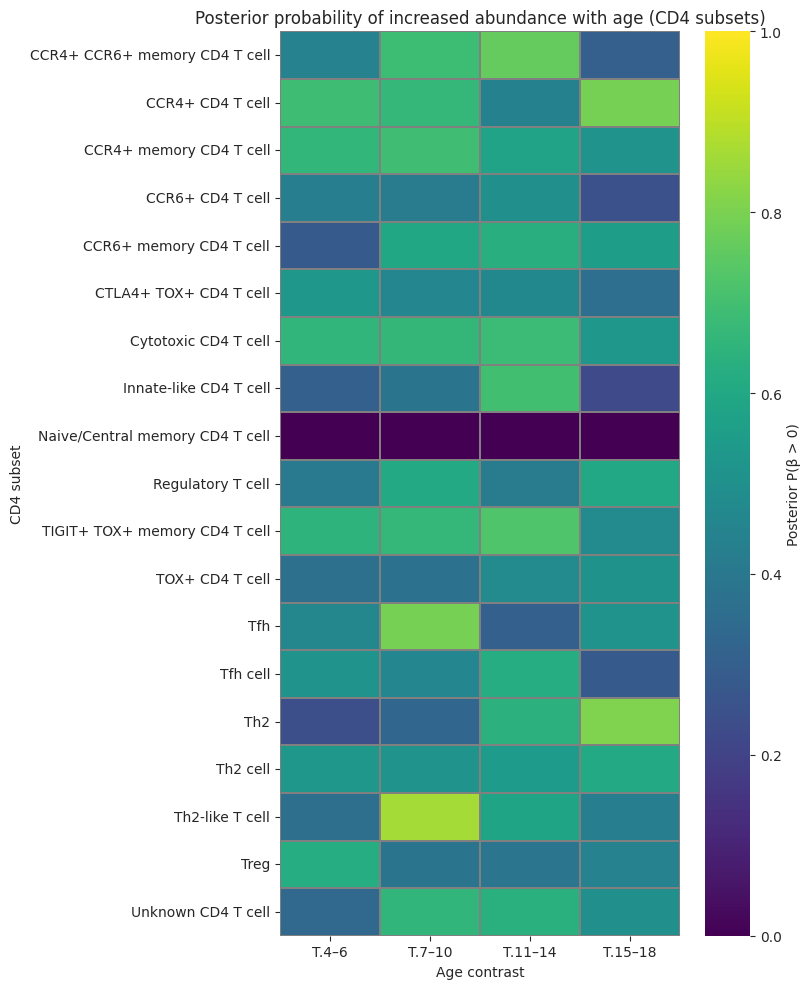

In [55]:
# heatmap across age groups
if "Age_group_2" in prob_df.columns:
    age_col = "Age_group_2"
else:
    age_col = "Age_group"

prob_heat = prob_df.pivot(
    index="cell_type",
    columns=age_col,
    values="p_gt0"
)

desired_order = ["T.4–6", "T.7–10", "T.11–14", "T.15–18"]

# keep only labels that exist in dataframe
desired_order = [a for a in desired_order if a in prob_heat.columns]

prob_heat = prob_heat.reindex(columns=desired_order)

# match forest plot order of cell types
prob_heat = prob_heat.loc[sorted(prob_heat.index)]

plt.figure(figsize=(8, 10))
sns.heatmap(
    prob_heat,
    vmin=0, vmax=1,
    cmap="viridis",
    cbar_kws={"label": "Posterior P(β > 0)"},
    linewidths=0.3,
    linecolor="grey"
)
plt.title("Posterior probability of increased abundance with age (CD4 subsets)")
plt.xlabel("Age contrast")
plt.ylabel("CD4 subset")
plt.tight_layout()
plt.show()


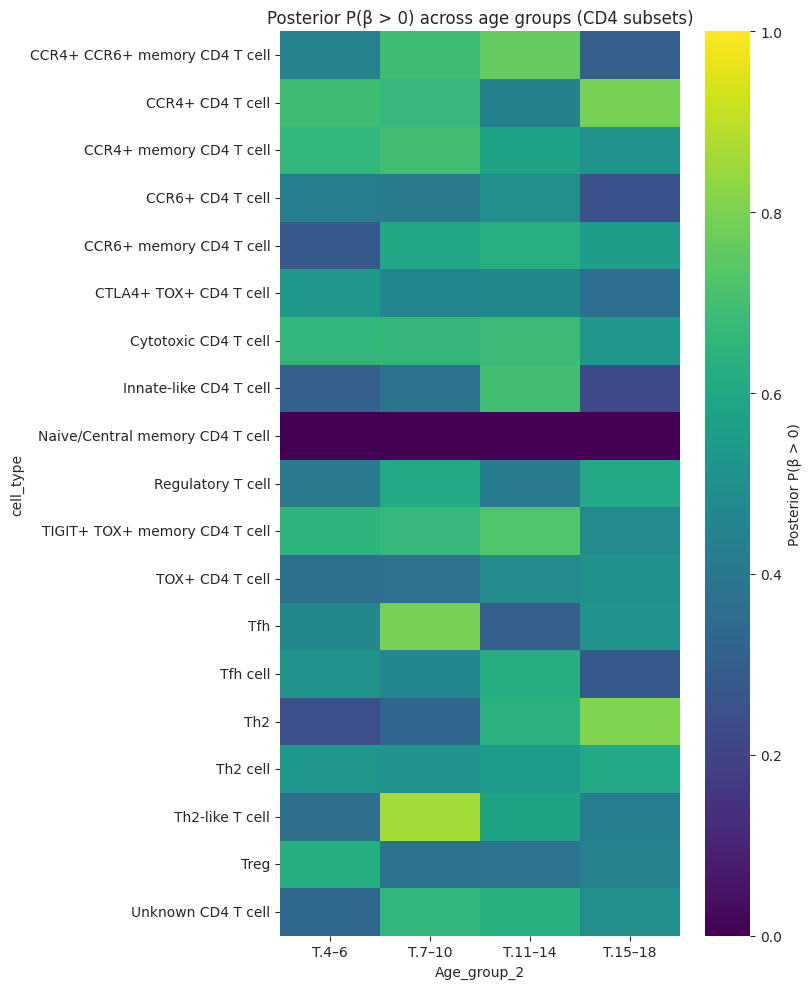

In [48]:
# mask cells that are not "strong"
mask = ~(
    (prob_heat >= 0.975) | (prob_heat <= 0.025)
)

plt.figure(figsize=(8, 10))
sns.heatmap(
    prob_heat,
    vmin=0, vmax=1,
    cmap="viridis",
    cbar_kws={"label": "Posterior P(β > 0)"},
    mask=None,  # show all cells, but we could add hatch for strong ones
)
plt.title("Posterior P(β > 0) across age groups (CD4 subsets)")
plt.tight_layout()
plt.show()

In [49]:
# Cell-type columns = everything except Age_group
cell_cols = [c for c in ct_table_with_meta.columns if c != "Age_group"]

# Convert counts → proportions per donor
prop_df = ct_table_with_meta[cell_cols].div(
    ct_table_with_meta[cell_cols].sum(axis=1),   # row sums over cell types
    axis=0
)

# Add Age_group for plotting
prop_df["Age_group"] = ct_table_with_meta["Age_group"]

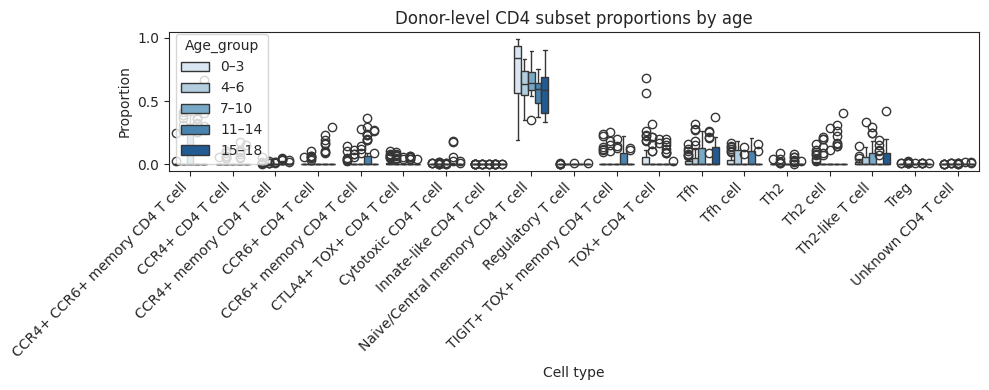

In [50]:
# Melt for plotting
prop_melt = (
    prop_df
    .reset_index()  # brings pica_id out of index
    .melt(
        id_vars=["pica_id", "Age_group"],
        var_name="Cell type",
        value_name="Proportion"
    )
)

plt.figure(figsize=(10, 4))
sns.boxplot(
    data=prop_melt,
    x="Cell type",
    y="Proportion",
    hue="Age_group",
    palette="Blues"
)
plt.title("Donor-level CD4 subset proportions by age")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()